In [3]:

%load_ext autoreload
%autoreload 2
import h5py
import numpy as np
import config
import autoencoder
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


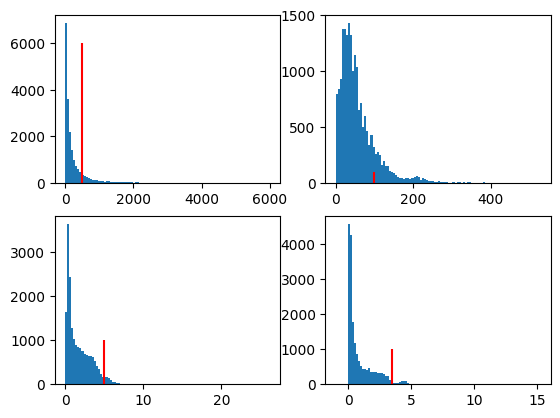

In [4]:


area = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='area')
circum = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='circum')
disloc = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='disloc')
eccen = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='eccen')
flags = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='flags')

thumbnails = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5')
proc = autoencoder.process_thumbnails(thumbnails)

fig, ax = plt.subplots(2,2)
ax[0,0].hist(area, bins=100)
ax[0,0].vlines(500, ymin=0, ymax=6000, color='red')
ax[0,1].hist(circum, bins=100)
ax[0,1].vlines(100, ymin=0, ymax=100, color='red')
ax[1,0].hist(disloc, bins=100)
ax[1,0].vlines(5, ymin=0, ymax=1000, color='red')
ax[1,1].hist(eccen, bins=100)
ax[1,1].vlines(3.5, ymin=0, ymax=1000, color='red')
      

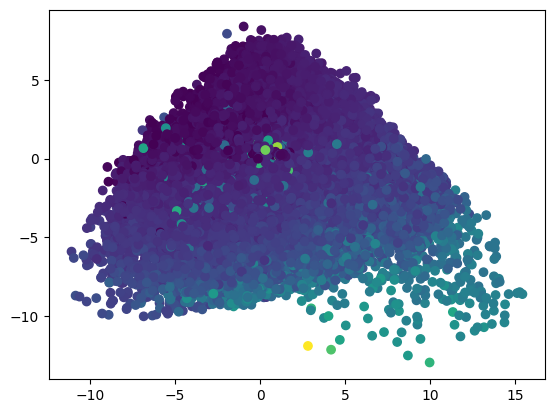

In [5]:
with h5py.File(f'{config.DATA_DIR}/coords_ld4.h5','r') as f:
    pca_coords = f['/pca_coords'][:]
    umap_coords = f['/umap_coords'][:]

plt.figure()
plt.scatter(pca_coords[:,0], pca_coords[:,1], c=circum)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Output()

Output()

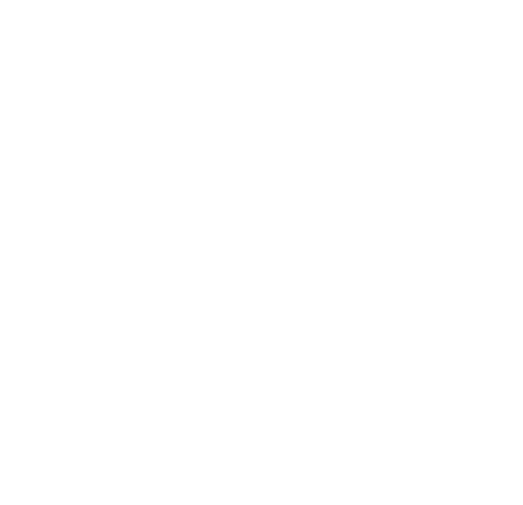

In [6]:

%load_ext autoreload
%autoreload 2

# 1. Import the class from your newly made script
from boxselector import BoxSelector
# 2. Instantiate the class by passing in your data variables
selector = BoxSelector(pca_coords, flags)
# 3. Call .show() to render everything beautifully in your cell
selector.show()

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np



with h5py.File('../data/thumbnails.h5','r') as f:
    print(f['/'].keys())
    print(f['/ferri'].keys())
    ferri = f['/ferri/thumbnails'][...]

<KeysViewHDF5 ['ferri', 'groel', 'ps20nm', 'ps30nm', 'ps40nm', 'ps50nm']>
<KeysViewHDF5 ['area', 'circum', 'disloc', 'eccen', 'flags', 'is', 'max', 'mean', 'median', 'min', 'thumbnails', 'xs', 'ys']>


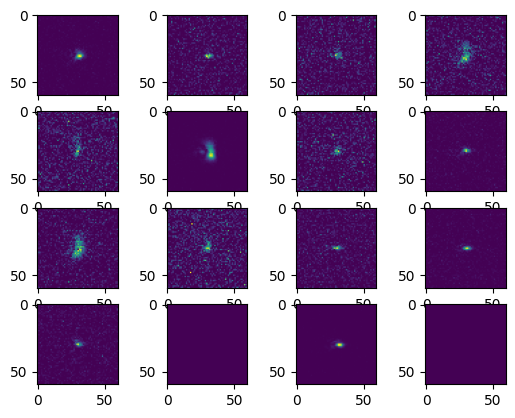

In [6]:
fig, axs = plt.subplots(4,4)
for ax in axs.flatten():
    ax.imshow(ferri[np.random.randint(0, ferri.shape[0]),:,:])
